### MID model simulation

This is a (nearly) from-scratch refactor of the MID simulation code, after we discovererd odd behavior in the original

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from poldracklab.fmri.spm_hrf import spm_hrf
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [95]:
# use data from both runs, concatenate them
def get_subdata(sub, run, verbose=False):
    sub = str(sub).zfill(2)
    events_df = None
    maxtime = None
    for run in [1,2]:
        eventfile = f'AHRB/sub-{sub}/ses-1/func/sub-{sub}_ses-1_task-mid_run-0{run}_events.tsv'
        df = pd.read_csv(eventfile, sep='\t')
        if verbose:
            print(f'Loading {eventfile}')
            print(df.shape)
        assert df.shape[1] > 2, f'bad parsing'
        if events_df is None:
            events_df = df
            maxtime = np.ceil(events_df['FEEDBACK_ONSET'].max() + events_df['FEEDBACK_DURATION'].values[-1])
        else:
            onset_cols = [col for col in df.columns if 'ONSET' in col]
            for col in onset_cols:
                df[col] += maxtime
            events_df = pd.concat([events_df, df])
    return events_df

events = get_subdata(1, 1, True)
print(events.shape)
print(events.TRIAL_TYPE.value_counts())
events.head()



Loading AHRB/sub-01/ses-1/func/sub-01_ses-1_task-mid_run-01_events.tsv
(50, 13)
Loading AHRB/sub-01/ses-1/func/sub-01_ses-1_task-mid_run-02_events.tsv
(50, 13)
(100, 13)
NoMoneyStake    20
LargeLoss       20
LargeGain       20
SmallLoss       20
SmallGain       20
Name: TRIAL_TYPE, dtype: int64


,TRIAL_TYPE,CUE_ONSET,CUE_DURATION,FIXATION_ONSET,FIXATION_DURATION,PROBE_ONSET,PROBE_DURATION,FEEDBACK_ONSET,FEEDBACK_DURATION,TRIAL_RESULT,RESULT_REASON,PROBE_HIT,PROBE_MRT
0,NoMoneyStake,0.058,2,2.008,2.0,4.007,0.319,4.407,1.631,No money at stake!,You pressed too slow!,0,0
1,NoMoneyStake,6.024,2,8.007,1.5,9.506,0.319,9.906,1.631,No money at stake!,You pressed too slow!,0,0
2,LargeLoss,11.556,2,13.506,2.5,16.005,0.319,16.405,1.631,You keep $5!,Correct Response!,1,306
3,NoMoneyStake,18.022,2,20.005,1.5,21.504,0.319,21.904,1.631,No money at stake!,Correct Response!,1,318
4,LargeGain,23.554,2,25.504,1.5,27.004,0.319,27.403,1.631,You did not earn $5!,You pressed too slow!,0,0


In [98]:
## create full design matrix with convolved regressors

def make_stick_function(onsets, durations, length, resolution=.1):
    """
    Create a stick function with onsets and durations

    Parameters
    ----------
    onsets : list
        List of onset times
    durations : list
        List of duration times
    length : float
        Length of the stick function (in seconds)
    resolution : float
        Resolution of the stick function (in seconds)
        0.1 secs by default
    
    Returns
    -------
    sf : np.array
        Timepoints of the stick function
    """
    timepoints = np.arange(0, length, resolution)
    sf = np.zeros_like(timepoints)
    for onset, duration in zip(onsets, durations):
        sf[(timepoints >= onset) & (timepoints < onset + duration)] = 1
    sf_df = pd.DataFrame({'sf': sf})
    sf_df.index = timepoints
    return sf_df

def create_design_matrix(events_df, resolution=.1, hrf_length=32, verbose=False):
    # create the full design matrix
    maxtime = np.ceil(events_df['FEEDBACK_ONSET'].max() + events_df['FEEDBACK_DURATION'].values[-1])
    timepoints = np.arange(0, maxtime, resolution)
    if verbose:
        print(f'Maxtime: {maxtime}')
        print(f'Timepoints: {timepoints.shape}')
    event_classes = ['CUE', 'FIXATION', 'PROBE', 'FEEDBACK']
    trial_types = events_df.TRIAL_TYPE.unique().tolist()
    desmtx = pd.DataFrame()
    desmtx_conv = pd.DataFrame()
    for trial_type in trial_types:
        for event_class in event_classes:
            if verbose:
                print(f'Creating stick function for {event_class}')
            if event_class != 'FEEDBACK':
                events_trialtype = events_df[events_df.TRIAL_TYPE == trial_type]
                onsets = events_trialtype[f'{event_class}_ONSET'].values
                durations = events_trialtype[f'{event_class}_DURATION'].values
                sf_df = make_stick_function(onsets, durations, maxtime)
                desmtx[f'{event_class}_{trial_type}'] = sf_df.sf.values
                desmtx_conv[f'{event_class}_{trial_type}'] = np.convolve(sf_df.sf.values, spm_hrf(resolution))[:sf_df.shape[0]]
            else:
                for probe_class in [1, 0]:
                    probe_str = 'HIT_' if probe_class == 1 else 'MISS_'
                    events_trialtype = events_df[(events_df.TRIAL_TYPE == trial_type) & (events_df.PROBE_HIT == probe_class)]
                    onsets = events_trialtype[f'{event_class}_ONSET'].values
                    durations = events_trialtype[f'{event_class}_DURATION'].values
                    sf_df = make_stick_function(onsets, durations, maxtime)
                    desmtx[f'{event_class}_{probe_str}{trial_type}'] = sf_df.sf.values
                    desmtx_conv[f'{event_class}_{probe_str}{trial_type}'] = np.convolve(sf_df.sf.values, spm_hrf(resolution))[:sf_df.shape[0]]
    # add cue + fix for later models
    # clip at 1 to deal with overlapping cues and fixations
    #desmtx['CUE_FIX'] = np.clip(desmtx['CUE'].values + desmtx['FIXATION'].values, 0, 1)
    #desmtx_conv['CUE_FIX'] = np.convolve(desmtx['CUE_FIX'].values, spm_hrf(resolution))[:sf_df.shape[0]]
    desmtx.index = timepoints
    desmtx_conv.index = timepoints
    return desmtx, desmtx_conv

desmtx, desmtx_conv = create_design_matrix(events)
print(desmtx.shape)
desmtx_conv.head()


(6300, 25)


,CUE_NoMoneyStake,FIXATION_NoMoneyStake,PROBE_NoMoneyStake,FEEDBACK_HIT_NoMoneyStake,FEEDBACK_MISS_NoMoneyStake,CUE_LargeLoss,FIXATION_LargeLoss,PROBE_LargeLoss,FEEDBACK_HIT_LargeLoss,FEEDBACK_MISS_LargeLoss,...,CUE_SmallLoss,FIXATION_SmallLoss,PROBE_SmallLoss,FEEDBACK_HIT_SmallLoss,FEEDBACK_MISS_SmallLoss,CUE_SmallGain,FIXATION_SmallGain,PROBE_SmallGain,FEEDBACK_HIT_SmallGain,FEEDBACK_MISS_SmallGain
0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.1,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.2,9.047147e-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.3,2.710054e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.4,2.070950e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


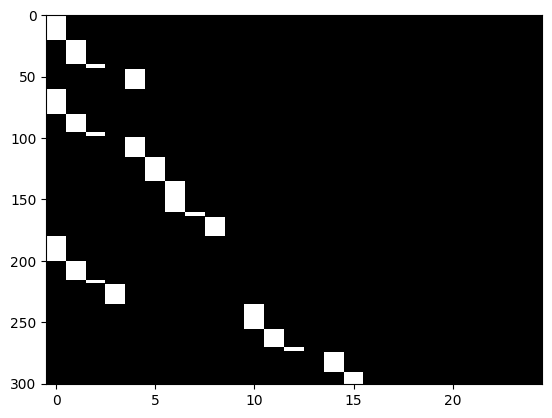

In [83]:
# Reality check for design matrix
plt.imshow(desmtx[:30], aspect='auto', cmap='gray', interpolation='nearest')

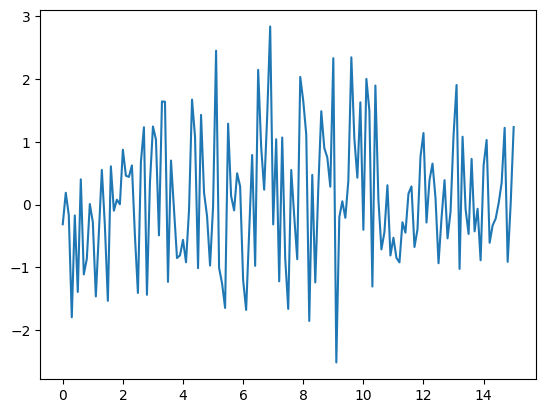

In [84]:
def generate_data(desmtx_conv, beta_dict, noise_sd=1):
    """
    Generate data based on the design matrix and beta values

    Parameters
    ----------

    desmtx_conv : pd.DataFrame
        Design matrix with convolved regressors
    beta_dict : dict
        Dictionary of beta values for each regressor of interest
    noise_sd : float
        Standard deviation of the noise
    """
    # check the beta dict
    betas = np.zeros(desmtx_conv.shape[1])
    for key in beta_dict.keys():
        assert key in desmtx_conv.columns, f'{key} not in desmtx'
    betas = [beta_dict[key] if key in beta_dict.keys() else 0 for key in desmtx_conv.columns ]

    data = np.dot(desmtx_conv.values, betas) + np.random.normal(0, noise_sd, desmtx_conv.shape[0])
    data_df = pd.DataFrame({'data': data})
    data_df.index = desmtx_conv.index
    return data_df

beta_dict = {'CUE_LargeGain': 1, 'CUE_SmallGain': 1} 
data = generate_data(desmtx_conv, beta_dict)
plt.plot(data.data[:15])


In [85]:
def convolve_regressors(sf, resolution=.1):
    sf_conv = pd.DataFrame(columns=sf.columns, index=sf.index)
    for col in sf.columns:
        sf_conv[col] = np.convolve(sf[col].values, 
                                spm_hrf(resolution))[:sf_conv.shape[0]]
    return sf_conv

dm_conv = convolve_regressors(desmtx)
dm_conv.head()

,CUE_NoMoneyStake,FIXATION_NoMoneyStake,PROBE_NoMoneyStake,FEEDBACK_HIT_NoMoneyStake,FEEDBACK_MISS_NoMoneyStake,CUE_LargeLoss,FIXATION_LargeLoss,PROBE_LargeLoss,FEEDBACK_HIT_LargeLoss,FEEDBACK_MISS_LargeLoss,...,CUE_SmallLoss,FIXATION_SmallLoss,PROBE_SmallLoss,FEEDBACK_HIT_SmallLoss,FEEDBACK_MISS_SmallLoss,CUE_SmallGain,FIXATION_SmallGain,PROBE_SmallGain,FEEDBACK_HIT_SmallGain,FEEDBACK_MISS_SmallGain
0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.1,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.2,9.047147e-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.3,2.710054e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.4,2.070950e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:


# create the three models
def create_models(sf):

    # 1. MID: Cue Onset, Cue Duration only 
    CueOnly = sf.copy()
    conds_to_drop = ['FIXATION', 'PROBE']
    for cond in sf.columns:
        if any([drop in cond for drop in conds_to_drop]):
            CueOnly.drop(cond, axis=1, inplace=True)

    return {'CueOnly': CueOnly}

models = create_models(desmtx)
models_conv = {key: convolve_regressors(value) for key, value in models.items()}

models_conv['CueOnly'].head()

,CUE_NoMoneyStake,FEEDBACK_HIT_NoMoneyStake,FEEDBACK_MISS_NoMoneyStake,CUE_LargeLoss,FEEDBACK_HIT_LargeLoss,FEEDBACK_MISS_LargeLoss,CUE_LargeGain,FEEDBACK_HIT_LargeGain,FEEDBACK_MISS_LargeGain,CUE_SmallLoss,FEEDBACK_HIT_SmallLoss,FEEDBACK_MISS_SmallLoss,CUE_SmallGain,FEEDBACK_HIT_SmallGain,FEEDBACK_MISS_SmallGain
0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.1,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.2,9.047147e-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.3,2.710054e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.4,2.070950e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


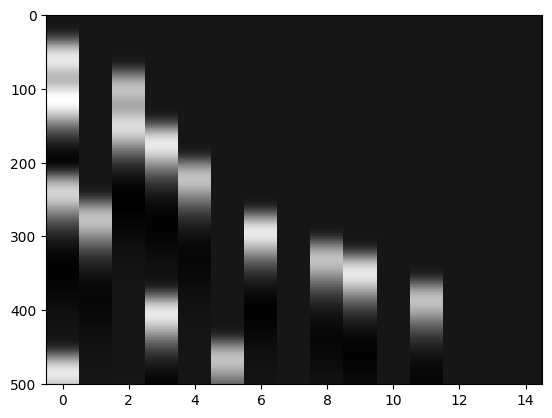

In [87]:
plt.imshow(models_conv['CueOnly'][:50], aspect='auto', cmap='gray', interpolation='nearest')

In [88]:
def get_coefficients_pvalues(ols_result):
    coef = ols_result.params
    pvals = ols_result.pvalues
    results = pd.DataFrame({'coef': coef, 'pvals': pvals})
    results.drop('const', inplace=True)
    return results

def run_model(model, data, add_constant=True):
    if add_constant:
        model =  sm.add_constant(model)
    return sm.OLS(data, model).fit()


model = run_model(models_conv['CueOnly'], data)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   data   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4.353
Date:                Sat, 06 Apr 2024   Prob (F-statistic):           3.76e-08
Time:                        06:03:24   Log-Likelihood:                -4424.8
No. Observations:                3150   AIC:                             8882.
Df Residuals:                    3134   BIC:                             8978.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [89]:

# Assume that 'model' is your fitted OLS model
# And 'params' are the names of your model's parameters

c = np.zeros(len(model.params))
# all win vs neutral
c[model.params.index == 'CUE_LargeGain'] = 1
c[model.params.index == 'CUE_SmallGain'] = 1
c[model.params.index == 'CUE_NoMoneyStake'] = -2
t_test = model.t_test(c)
print(t_test)

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.4169      0.337      4.208      0.000       0.757       2.077


In [90]:
model.params.index

Index(['const', 'CUE_NoMoneyStake', 'FEEDBACK_HIT_NoMoneyStake',
       'FEEDBACK_MISS_NoMoneyStake', 'CUE_LargeLoss', 'FEEDBACK_HIT_LargeLoss',
       'FEEDBACK_MISS_LargeLoss', 'CUE_LargeGain', 'FEEDBACK_HIT_LargeGain',
       'FEEDBACK_MISS_LargeGain', 'CUE_SmallLoss', 'FEEDBACK_HIT_SmallLoss',
       'FEEDBACK_MISS_SmallLoss', 'CUE_SmallGain', 'FEEDBACK_HIT_SmallGain',
       'FEEDBACK_MISS_SmallGain'],
      dtype='object')